C:\Users\whdal\AppData\Local\Temp\ipykernel_33204\349808926.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['IdMax'] = pd.to_numeric(df['IdMax'], errors='coerce')
C:\Users\whdal\AppData\Local\Temp\ipykernel_33204\349808926.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['block'] = df['IdMax'].notna().cumsum()


                    Vgate Vdrain                    Idrain         IdMax  \
419                    -3    0.1    1.1370000000000001E-12  2.272750e-07   
420                 -2.95    0.1    3.3000000000000005E-14           NaN   
421                  -2.9    0.1                   6.2E-14           NaN   
422                 -2.85    0.1                   7.1E-14           NaN   
423   -2.8000000000000003    0.1                  -4.1E-14           NaN   
424                 -2.75    0.1                 -1.34E-13           NaN   
425                  -2.7    0.1                   2.9E-14           NaN   
426                 -2.65    0.1                 -2.24E-13           NaN   
427                  -2.6    0.1   -1.6600000000000003E-13           NaN   
428   -2.5500000000000003    0.1                 -3.39E-13           NaN   
429                  -2.5    0.1   -2.6400000000000004E-13           NaN   
430                 -2.45    0.1   -3.0200000000000003E-13           NaN   
431         

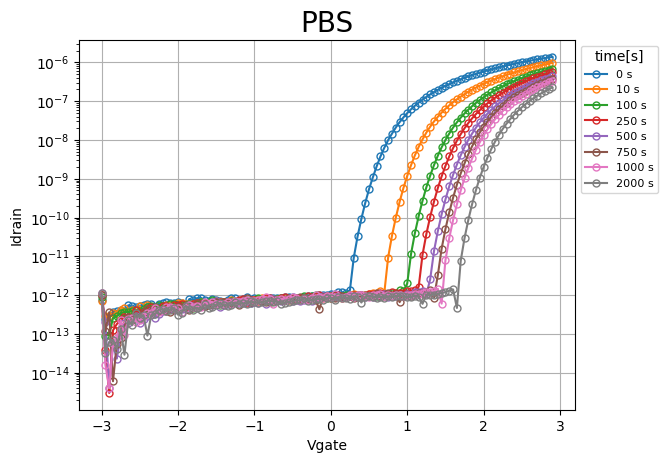

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv


path = "PBTI_IGZO_new2 [260331_WF02_#5_40_20_1_R2_PBS(1) ; 4_9_2026 11_52_52 AM].csv"
# csv 鍮덉뭏 ?댁씠 ?쒖옟?좊븣 洹몃?濡??ㅺ퀬?ㅻ뒗 肄붾뱶
rows = []
with open(path, "r", encoding="utf-8-sig", errors="replace", newline="") as f:
    reader = csv.reader(f)
    for r in reader:
        rows.append(r)

max_len = max(len(r) for r in rows)
rows = [r + [""] * (max_len - len(r)) for r in rows]  # 遺議깊븳 ?댁? 鍮덉뭏?쇰줈 梨꾩?

raw_data = pd.DataFrame(rows)  # 紐⑤뱺 ???蹂댁〈??n

# ?먰븯???곗씠?곕쭔 ?ㅺ퀬?ㅺ린
raw_data2 = raw_data[0].isin(['DataValue'])

raw_data = raw_data[raw_data2]
raw_data = raw_data.iloc[:,1:6]
raw_data.columns = ['Vgate','Vdrain','Idrain','IdMax','Vth@Id']


df = raw_data

time = df.loc[df['Idrain'].isin([' ']),'Vgate']
time_list = time.tolist()
time_list = list(reversed(time_list))
time_count = len(time_list)
df = df.iloc[time_count:,:]

df['IdMax'] = pd.to_numeric(df['IdMax'], errors='coerce')

# 1) IdMax媛 議댁옱?섎뒗 ?됰쭏??釉붾줉 踰덊샇 1,2,3,... 利앷?
df['block'] = df['IdMax'].notna().cumsum()

# (?좏깮) 留뚯빟 IdMax ?섏삤湲???援ш컙???덉쑝硫?block=0?몃뜲, 蹂댄넻 ?꾩슂 ?놁쑝???쒓굅
df = df[df['block'] > 0].copy()

# 2) block 踰덊샇瑜?time_list??留ㅽ븨
#    block=1 -> time_list[0], block=2 -> time_list[1], ...
mapping = {i + 1: t for i, t in enumerate(time_list)}

df['time_s'] = df['block'].map(mapping)



# 5) ?뺣━: ?꾩슂 ?녿뒗 block 而щ읆 ?쒓굅?섍퀬 ?뺤씤
print(df[['Vgate','Vdrain','Idrain','IdMax','time_s']].head(30))


df['Vgate']  = pd.to_numeric(df['Vgate'], errors='coerce')
df['Idrain'] = pd.to_numeric(df['Idrain'], errors='coerce').abs()
df['time_s'] = pd.to_numeric(df['time_s'], errors='coerce')

# 2) ?좏슚媛믩쭔 ?④린湲?n
plot_df = df.dropna(subset=['Vgate', 'Idrain', 'time_s']).copy()

# (?좏깮) time ?쒖꽌 ?뺣젹
times = sorted(plot_df['time_s'].unique())

plt.figure()

for t in times:
    d = plot_df[plot_df['time_s'] == t].sort_values('Vgate')
    plt.semilogy(d['Vgate'].to_numpy(), d['Idrain'].to_numpy(),marker = 'o',markerfacecolor = 'none', markersize = 5,linestyle='-', label=f'{int(t)} s')



plt.xlabel('Vgate')
plt.ylabel('Idrain')
plt.title('PBS', fontsize = 20)
plt.legend(title = 'time[s]',bbox_to_anchor=(1, 1), loc='upper left', fontsize = 8)   
plt.grid(True)
plt.show()

In [16]:
target1 = -10                               # log(ID) = -10???寃잛엫(vth ?곗텧??
target2 = -9                                # SS ?곗텧??n
vth_by_time_10 = {}  # time蹂?Vth ???n
vth_by_time_9 = {}  # time蹂?Vth ???n
for vd, g in df.groupby('time_s'):              # ?욎뿉 ?덈뒗 vd??df.groupby('VD')??key??'VD'瑜?諛쏅뒗寃껋씠怨??ㅼ뿉 ?덈뒗 g??key 'VD'???대떦?섎뒗 媛믪쓣 諛쏅뒗??
    g = g.sort_values('Idrain')

    VG = g['Vgate'].to_numpy()                 # VG column???レ옄濡?蹂??n
    ID = g['Idrain'].to_numpy()                 # ID column???レ옄濡?蹂??n

    # log10(|ID|) 怨꾩궛: 0? 濡쒓렇 遺덇? ???꾩＜ ?묒? 媛믪쑝濡??대━??n
    absID = np.abs(ID)
    absID = np.clip(absID, 1e-300, None)   # underflow 諛⑹?
    logI = np.log10(absID)

     # ===== 3) target 援먯감 援ш컙 ?먯깋 + ?좏삎 蹂닿컙 =====
    diff1 = logI - target1
    diff2 = logI - target2
    cross_idx_10 = np.where(diff1[:-1] * diff1[1:] <= 0)[0]  # target???ъ씠???먮뒗 ?몄젒 ???끸쁾?끸쁾?끸쁾?끸쁾?끸쁾?끸쁾 np.where(condition,True,False))
    cross_idx_9 = np.where(diff2[:-1] * diff2[1:] <= 0)[0] 

    if len(cross_idx_10) == 0:
        vth_by_time_10[vd] = np.nan
        continue
    if len(cross_idx_9) == 0:
        vth_by_time_9[vd] = np.nan
        continue
    # 泥?踰덉㎏ crossing ?ъ슜 (?먰븯硫?留덉?留?crossing: cross_idx[-1])
    i1 = cross_idx_10[0]
    i2 = cross_idx_9[0]

    x0, x1 = VG[i1], VG[i1+1]
    y0, y1 = logI[i1], logI[i1+1]

    z0, z1 = VG[i2], VG[i2+1]
    t0, t1 = logI[i2], logI[i2+1]    

    # 遺꾨え 0 諛⑹?
    if y1 == y0:
        vth_10 = np.nan
    else:
        vth_10 = x0 + (target1 - y0) * (x1 - x0) / (y1 - y0)

    vth_by_time_10[vd] = vth_10
    
    # 遺꾨え 0 諛⑹?
    if t1 == t0:
        vth_9 = np.nan
    else:
        vth_9 = z0 + (target2 - t0) * (z1 - z0) / (t1 - t0)

    vth_by_time_9[vd] = vth_9
    
# ===== 5) VD蹂?Vth 異쒕젰 =====
print(f"Vth @ log10(|ID|) = {target1} (by times)")
for vd in sorted(vth_by_time_10.keys()):
    print(f"times={vd}[s]: Vth={vth_by_time_10[vd]:.2f}")

    # ===== 6) VD蹂?SS 怨꾩궛 =====
ss_by_vd = {}  # VD蹂?SS ???(mV/dec)

for vd in vth_by_time_10.keys():
    vg_at_10 = vth_by_time_10.get(vd, np.nan)  # log|ID|=-10?먯꽌 VG
    vg_at_9  = vth_by_time_9.get(vd, np.nan)   # log|ID|=-9?먯꽌 VG

    # ??以??섎굹?쇰룄 NaN?대㈃ SS??NaN
    if np.isnan(vg_at_10) or np.isnan(vg_at_9):
        ss_by_vd[vd] = np.nan
    else:
        ss_v_per_dec = (vg_at_9 - vg_at_10) / (target2 - target1)  # ?ш린?쒕뒗 /1?대씪 ?숈씪?섏?留??쇰컲?앹쑝濡??묒꽦
        ss_by_vd[vd] = ss_v_per_dec * 1000  # mV/dec

# ===== 7) VD蹂?SS 異쒕젰 =====
print(f"SS (mV/dec) using log10(|ID|)={target1} to {target2} (by times)")
for vd in sorted(ss_by_vd.keys()):
    print(f"times={vd}[s]: Vth={vth_by_time_10[vd]:.2f}, SS={ss_by_vd[vd]:.2f}")

Vth @ log10(|ID|) = -10 (by times)
times=0[s]: Vth=0.40
times=10[s]: Vth=0.85
times=100[s]: Vth=1.15
times=250[s]: Vth=1.30
times=500[s]: Vth=1.44
times=750[s]: Vth=1.53
times=1000[s]: Vth=1.61
times=2000[s]: Vth=1.81
SS (mV/dec) using log10(|ID|)=-10 to -9 (by times)
times=0[s]: Vth=0.40, SS=140.09
times=10[s]: Vth=0.85, SS=137.26
times=100[s]: Vth=1.15, SS=141.38
times=250[s]: Vth=1.30, SS=142.10
times=500[s]: Vth=1.44, SS=142.43
times=750[s]: Vth=1.53, SS=141.77
times=1000[s]: Vth=1.61, SS=140.15
times=2000[s]: Vth=1.81, SS=138.70


In [17]:
print(df)

      Vgate Vdrain        Idrain         IdMax Vth@Id  block  time_s
419   -3.00    0.1  1.137000e-12  2.272750e-07    2.9      1    2000
420   -2.95    0.1  3.300000e-14           NaN    2.9      1    2000
421   -2.90    0.1  6.200000e-14           NaN    2.9      1    2000
422   -2.85    0.1  7.100000e-14           NaN    2.9      1    2000
423   -2.80    0.1  4.100000e-14           NaN    2.9      1    2000
...     ...    ...           ...           ...    ...    ...     ...
3186   2.70    0.1  1.188790e-06           NaN    2.9      8       0
3187   2.75    0.1  1.236980e-06           NaN    2.9      8       0
3188   2.80    0.1  1.285170e-06           NaN    2.9      8       0
3189   2.85    0.1  1.333850e-06           NaN    2.9      8       0
3190   2.90    0.1  1.382960e-06           NaN    2.9      8       0

[952 rows x 7 columns]


Delta Vth reference: time=0[s], Vth=0.40 V
time=0[s]: Delta Vth=0.00 V
time=10[s]: Delta Vth=0.45 V
time=100[s]: Delta Vth=0.74 V
time=250[s]: Delta Vth=0.89 V
time=500[s]: Delta Vth=1.04 V
time=750[s]: Delta Vth=1.13 V
time=1000[s]: Delta Vth=1.20 V
time=2000[s]: Delta Vth=1.40 V


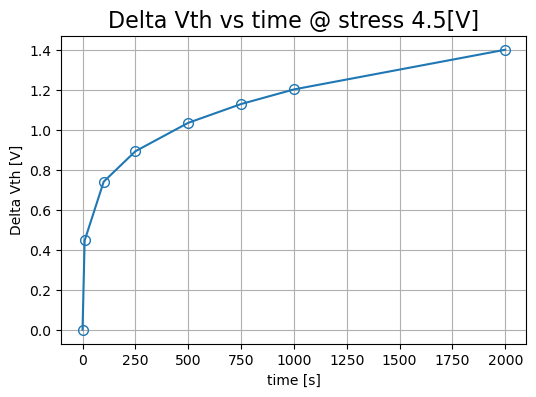

In [18]:
# time별 Delta Vth 계산 및 그래프
delta_vth_ref_time = min(vth_by_time_10.keys())
delta_vth_ref_value = vth_by_time_10[delta_vth_ref_time]

delta_vth_by_time = {}
for t in sorted(vth_by_time_10.keys()):
    vth_val = vth_by_time_10[t]
    if np.isnan(vth_val) or np.isnan(delta_vth_ref_value):
        delta_vth_by_time[t] = np.nan
    else:
        delta_vth_by_time[t] = vth_val - delta_vth_ref_value

delta_vth_df = pd.DataFrame({
    'time_s': sorted(delta_vth_by_time.keys()),
    'delta_vth': [delta_vth_by_time[t] for t in sorted(delta_vth_by_time.keys())]
})

print(f"Delta Vth reference: time={delta_vth_ref_time}[s], Vth={delta_vth_ref_value:.2f} V")
for _, row in delta_vth_df.iterrows():
    print(f"time={int(row['time_s'])}[s]: Delta Vth={row['delta_vth']:.2f} V")

plt.figure(figsize=(6, 4))
plt.plot(
    delta_vth_df['time_s'],
    delta_vth_df['delta_vth'],
    marker='o',
    markerfacecolor='none',
    markersize=7,
    linewidth=1.5
)
plt.xlabel('time [s]')
plt.ylabel('Delta Vth [V]')
plt.title('Delta Vth vs time @ stress 4.5[V]', fontsize=16)
plt.grid(True)
plt.show()